In [ ]:
import pandas as pd
import numpy as np

# Import dataset
df = pd.read_csv("Model_Ready.csv")


# Drop incomplete rows
df.dropna()

,month,total_visits,total_people_served,unique_clients,unique_households,avg_household_size,avg_client_age,ow_cases_official,ow_beneficiaries,odsp_cases_official,...,ow_beneficiaries_lag1,odsp_cases_official_lag1,odsp_beneficiaries_lag1,total_homeless_lag1,total_chronic_homeless_lag1,cpi_all_items_lag1,cpi_food_lag1,cpi_shelter_lag1,unemployment_lag1,unemployment_rate_lag1
49,2019-02-01,5519,15168,3685,3582,2.573981,44.001365,9173,17440,12728,...,17353.0,12724.0,17491.0,754.0,293.0,135.2,151.6,145.0,438200.0,5.6
50,2019-03-01,6309,17519,4063,3910,2.579795,44.249628,9063,17176,12783,...,17440.0,12728.0,17528.0,725.0,298.0,136.0,151.9,145.5,436300.0,5.6
51,2019-04-01,5965,16438,3851,3703,2.565757,44.643551,9133,17353,12742,...,17176.0,12783.0,17615.0,738.0,302.0,137.0,151.9,145.8,457300.0,5.9
52,2019-05-01,6790,19111,4232,4068,2.618486,44.429254,9255,17641,12800,...,17353.0,12742.0,17578.0,764.0,327.0,137.4,151.8,146.5,464100.0,5.9
53,2019-06-01,5812,16486,3825,3681,2.641130,44.806033,9243,17637,12680,...,17641.0,12800.0,17646.0,758.0,363.0,138.1,152.7,146.6,407400.0,5.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133,2026-02-01,16569,53193,9117,8725,3.014900,45.286767,10805,18604,13473,...,18742.0,13410.0,18236.0,1448.0,1031.0,165.9,203.5,189.6,644500.0,7.3
134,2026-03-01,18615,59298,9637,9262,3.000972,45.369412,10925,18735,13594,...,18604.0,13473.0,18295.0,1431.0,1014.0,166.7,203.4,189.3,672400.0,7.6
135,2026-04-01,18937,60647,9437,9080,2.989978,45.632561,10839,18702,13672,...,18735.0,13594.0,18487.0,1490.0,1039.0,168.2,204.4,189.9,676100.0,7.6
136,2026-05-01,17610,55440,9467,9094,2.987024,45.602482,10827,18708,13689,...,18702.0,13672.0,18585.0,1540.0,1059.0,168.8,203.8,189.6,672900.0,7.5


# **Train**

In [ ]:
# Sort chronologically
df = df.sort_values("month")

df["log_people_served"] = np.log(
    df["total_people_served"]
)

# Split point

#train = df[(df["month"] < "2025-07-01")]
train = df[(df["month"] >= "2022-07-01") & (df["month"] < "2025-07-01")]

test = df[df["month"] >= "2025-07-01"]

print(train.shape)
print(test.shape)

features = [
    "year",
    "month_num",
    "quarter",

    # target history
    "total_people_served_lag1",
    "total_people_served_lag2",
    "total_people_served_lag3",
    "total_people_served_lag6",
    "total_people_served_lag12",

    # trend
    "total_people_served_rollingavg3",
    "total_people_served_rollingavg6",
    "total_people_served_rollingavg12",

    # previous month external indicators

    "ow_cases_official_lag1",
    "odsp_cases_official_lag1",
    "total_homeless_lag1",
    "total_chronic_homeless_lag1",
    "cpi_all_items_lag1",
    "cpi_food_lag1",
    "cpi_shelter_lag1",
    "unemployment_rate_lag1"
]

X_train = train[features]
y_train = train["total_people_served"]

X_test = test[features]
y_test = test["total_people_served"]

(36, 41)
(12, 41)


# **Test**

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=5,
    min_samples_leaf=2,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

y_pred = rf.predict(X_test)


results = test[["month", "total_people_served"]].copy()

results["prediction"] = y_pred

results.head()

,month,total_people_served,prediction
126,2025-07-01,57442,54180.944895
127,2025-08-01,52818,53748.974038
128,2025-09-01,53545,54161.116417
129,2025-10-01,60473,54273.422850
130,2025-11-01,55296,55267.645521


# **Error**

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)

wape = (
    np.sum(np.abs(y_test - y_pred)) /
    np.sum(np.abs(y_test))
)




print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)
print("WAPE %:", wape * 100)

MAE: 3005.9461672619086
RMSE: 3823.7620640882556
R²: -0.620070478878614
WAPE %: 5.3780369049110055


# **Comparison to Actual**

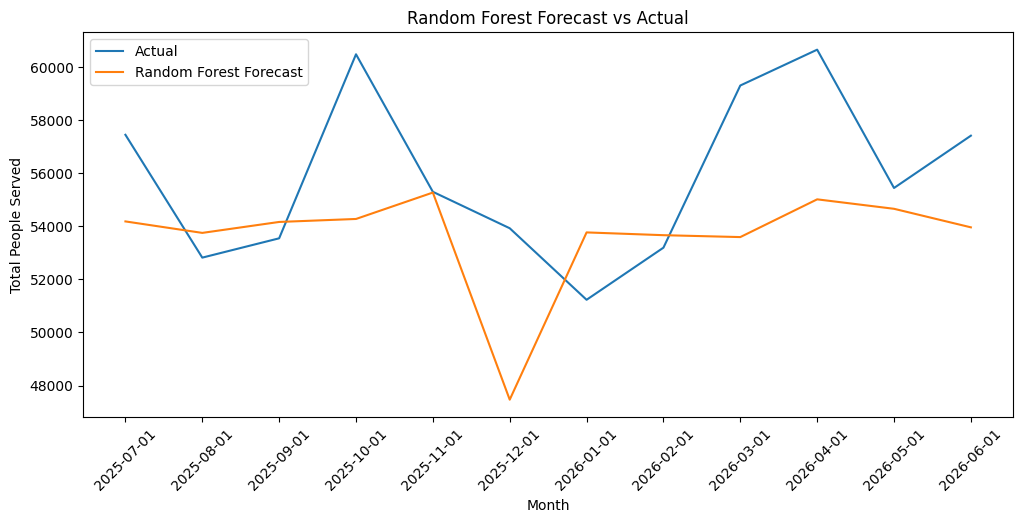

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    results["month"],
    results["total_people_served"],
    label="Actual"
)

plt.plot(
    results["month"],
    results["prediction"],
    label="Random Forest Forecast"
)

plt.xlabel("Month")
plt.ylabel("Total People Served")
plt.title("Random Forest Forecast vs Actual")
plt.legend()
plt.xticks(rotation=45)

plt.show()

# **Feature Importance**

In [ ]:
importance = pd.DataFrame({
    "feature": features,
    "importance": rf.feature_importances_
})

importance.sort_values(
    "importance",
    ascending=False
)

,feature,importance
7,total_people_served_lag12,0.369413
6,total_people_served_lag6,0.172257
11,ow_cases_official_lag1,0.068004
5,total_people_served_lag3,0.061909
15,cpi_all_items_lag1,0.044665
14,total_chronic_homeless_lag1,0.035545
4,total_people_served_lag2,0.034096
9,total_people_served_rollingavg6,0.032583
17,cpi_shelter_lag1,0.030878
16,cpi_food_lag1,0.029304


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def generate_model_report(
    model_name,
    model,
    target,
    train,
    test,
    features,
    y_test,
    y_pred,
    changes_made="",
    why_changed=""
):

    # ==========================
    # Performance Metrics
    # ==========================

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )

    r2 = r2_score(
        y_test,
        y_pred
    )

    wape = (
        np.sum(np.abs(y_test - y_pred))
        /
        np.sum(np.abs(y_test))
    )

    bias = np.mean(
        y_pred - y_test
    )


    # ==========================
    # Feature Importance
    # ==========================

    feature_importance = pd.DataFrame({
        "feature": features,
        "importance": model.feature_importances_
    })

    feature_importance = (
        feature_importance
        .sort_values(
            "importance",
            ascending=False
        )
    )

    top5 = feature_importance.head(5)


    # ==========================
    # Largest Errors
    # ==========================

    errors = pd.DataFrame({
        "month": test["month"].values,
        "actual": y_test.values,
        "prediction": y_pred,
    })


    errors["absolute_error"] = (
        abs(
            errors["actual"]
            -
            errors["prediction"]
        )
    )


    largest_errors = (
        errors
        .sort_values(
            "absolute_error",
            ascending=False
        )
        .head(5)
    )


    # ==========================
    # Print Report
    # ==========================

    print("="*60)
    print("MODEL REPORT")
    print("="*60)


    print("\nModel Name:")
    print(model_name)


    print("\nTarget:")
    print(target)


    print("\nFeatures:")
    for f in features:
        print("-", f)


    print("\nTrain Period:")
    print(
        train["month"].min(),
        "to",
        train["month"].max()
    )


    print("\nTest Period:")
    print(
        test["month"].min(),
        "to",
        test["month"].max()
    )


    print("\n\nPerformance:")
    print("----------------")
    print(
        f"WAPE: {wape*100:.2f}%"
    )

    print(
        f"MAE: {mae:,.0f}"
    )

    print(
        f"RMSE: {rmse:,.0f}"
    )

    print(
        f"Bias: {bias:,.0f}"
    )

    print(
        f"R2: {r2:.3f}"
    )


    print("\n\nInterpretation:")
    print("----------------")

    print("\nTop 5 Features:")
    print(top5.to_string(index=False))


    print("\n\nLargest Errors:")
    print(largest_errors.to_string(index=False))


    print("\n\nNotes:")
    print("----------------")


    return {
        "metrics": {
            "WAPE": wape,
            "MAE": mae,
            "RMSE": rmse,
            "Bias": bias,
            "R2": r2
        },
        "feature_importance": feature_importance,
        "largest_errors": largest_errors
    }



In [ ]:
report = generate_model_report(
    model_name="Random Forest Baseline",

    model=rf,

    target="total_people_served",

    train=train,

    test=test,

    features=features,

    y_test=y_test,

    y_pred=y_pred
)

MODEL REPORT

Model Name:
Random Forest Baseline

Target:
total_people_served

Features:
- year
- month_num
- quarter
- total_people_served_lag1
- total_people_served_lag2
- total_people_served_lag3
- total_people_served_lag6
- total_people_served_lag12
- total_people_served_rollingavg3
- total_people_served_rollingavg6
- total_people_served_rollingavg12
- ow_cases_official_lag1
- odsp_cases_official_lag1
- total_homeless_lag1
- total_chronic_homeless_lag1
- cpi_all_items_lag1
- cpi_food_lag1
- cpi_shelter_lag1
- unemployment_rate_lag1

Train Period:
2022-07-01 to 2025-06-01

Test Period:
2025-07-01 to 2026-06-01


Performance:
----------------
WAPE: 5.38%
MAE: 3,006
RMSE: 3,824
Bias: -2,247
R2: -0.620


Interpretation:
----------------

Top 5 Features:
                  feature  importance
total_people_served_lag12    0.369413
 total_people_served_lag6    0.172257
   ow_cases_official_lag1    0.068004
 total_people_served_lag3    0.061909
       cpi_all_items_lag1    0.044665


Larges